# Actual vs predicted prices over time

This notebook has one purpose: show how the final forecast follows the actual NEM price through time.

- The top panel gives a downsampled view of the complete test period.
- The bottom panel keeps the native five-minute observations for a detailed event window.
- If no start date is supplied, the detailed window is centred on the highest actual price.

The horizontal axis uses **delivery time** (forecast origin plus the selected horizon), so each prediction is aligned with the period it forecasts.

In [7]:
from pathlib import Path
import sys

import matplotlib.dates as mdates
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyarrow.parquet as pq

# Find the repository root whether Jupyter starts here or in the notebook folder.
PROJECT_ROOT = next(
    path for path in (Path.cwd(), *Path.cwd().parents)
    if (path / "EPF" / "variables.py").exists()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from EPF import variables

# --------------------------- plot controls ---------------------------
HORIZON = 40                 # 1..96; each step is 30 minutes
DETAIL_START = None          # e.g. "2025-03-12"; None selects the largest price event
DETAIL_DAYS = 7
OVERVIEW_RULE = "6h"       # aggregate the full-period panel for readability
SHOW_CENTRAL_PREDICTION = True
SHOW_BASELINES = False       # optional naive and AEMO predispatch lines
USE_SYMLOG_SCALE = True      # preserves spikes without flattening normal-price periods
SAVE_FIGURE = True

PREDICTIONS_PATH = Path(variables.ACTUAL_VS_PREDICTED_TEST_SET)
FIGURE_DIR = Path(variables.CWD) / "6_Analysis" / "plots"

## Load only the selected horizon

The final tail-aware forecast is used when it is available. The central stacked forecast can be retained as a comparison, while the naive and AEMO baselines are optional.

In [8]:
def load_horizon_frame(horizon: int) -> tuple[pd.DataFrame, str]:
    if not PREDICTIONS_PATH.exists():
        raise FileNotFoundError(
            f"Missing {PREDICTIONS_PATH}. Run the model evaluation step first."
        )
    if not 1 <= horizon <= variables.HORIZON_COUNT:
        raise ValueError(f"HORIZON must be between 1 and {variables.HORIZON_COUNT}.")

    available = set(pq.ParquetFile(PREDICTIONS_PATH).schema.names)
    actual_col = f"actual_h{horizon}"
    central_col = f"predicted_h{horizon}"
    tail_col = f"tail_aware_h{horizon}"
    final_col = tail_col if tail_col in available else central_col

    required = {actual_col, final_col}
    missing = required - available
    if missing:
        raise KeyError(f"Prediction file is missing required columns: {sorted(missing)}")

    columns = [actual_col, final_col]
    rename = {
        actual_col: "Actual",
        final_col: "Tail-aware prediction" if final_col == tail_col else "Prediction",
    }

    if SHOW_CENTRAL_PREDICTION and central_col in available and central_col != final_col:
        columns.append(central_col)
        rename[central_col] = "Central prediction"

    if SHOW_BASELINES:
        optional = {
            f"naive_h{horizon}": "Naive forecast",
            f"aemo_predispatch_h{horizon}": "AEMO predispatch",
        }
        for column, label in optional.items():
            if column in available:
                columns.append(column)
                rename[column] = label

    frame = pd.read_parquet(PREDICTIONS_PATH, columns=columns).rename(columns=rename)
    frame.index = pd.to_datetime(frame.index)
    frame = frame.sort_index()

    # Stored timestamps are forecast origins. Shift to the target delivery time.
    lead = pd.Timedelta(
        minutes=horizon * variables.HORIZON_GRANULARITY_IN_MINUTES
    )
    frame.index = frame.index + lead
    frame.index.name = "delivery_time"
    frame = frame.dropna(subset=["Actual", rename[final_col]])

    return frame, rename[final_col]


forecast_df, final_prediction_label = load_horizon_frame(HORIZON)
lead_hours = HORIZON * variables.HORIZON_GRANULARITY_IN_MINUTES / 60
print(
    f"Loaded {len(forecast_df):,} aligned observations for h{HORIZON} "
    f"({lead_hours:g} hours ahead), from {forecast_df.index.min()} to "
    f"{forecast_df.index.max()}. Final series: {final_prediction_label}."
)

Loaded 105,120 aligned observations for h40 (20 hours ahead), from 2025-01-01 20:05:00 to 2026-01-01 20:00:00. Final series: Tail-aware prediction.


## Actual vs predicted time series

Saved figure to /home/daniel-davaris/Documents/NEM-Short-Term-Price-Forecasting/EPF/6_Analysis/plots/actual_vs_predicted_h40.png


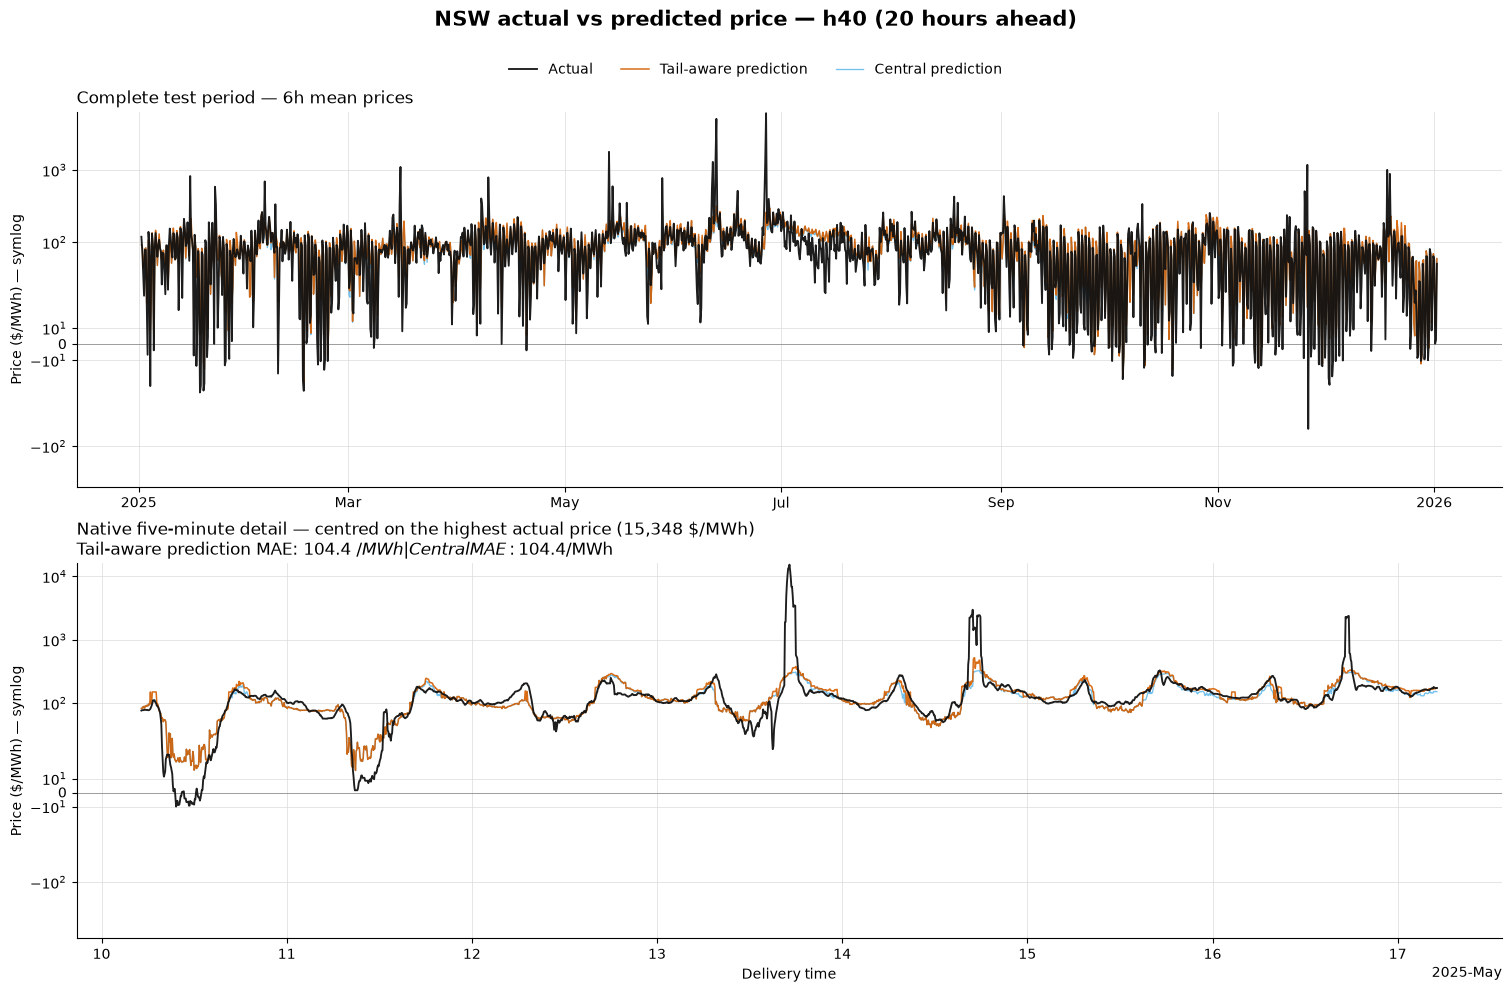

In [9]:
SERIES_STYLES = {
    "Actual": dict(color="#111111", linewidth=1.35, alpha=0.95, zorder=5),
    "Tail-aware prediction": dict(color="#D55E00", linewidth=1.10, alpha=0.90, zorder=4),
    "Prediction": dict(color="#0072B2", linewidth=1.10, alpha=0.90, zorder=4),
    "Central prediction": dict(color="#56B4E9", linewidth=0.95, alpha=0.82, zorder=3),
    "Naive forecast": dict(color="#7A7A7A", linewidth=0.85, alpha=0.72, linestyle="--", zorder=2),
    "AEMO predispatch": dict(color="#009E73", linewidth=0.85, alpha=0.72, linestyle="--", zorder=2),
}


def select_detail_window(
    frame: pd.DataFrame,
    start: str | pd.Timestamp | None,
    days: int,
) -> tuple[pd.DataFrame, str]:
    if days <= 0:
        raise ValueError("DETAIL_DAYS must be positive.")

    duration = pd.Timedelta(days=days)
    if start is None:
        event_time = frame["Actual"].idxmax()
        window_start = event_time - duration / 2
        reason = f"centred on the highest actual price ({frame.loc[event_time, 'Actual']:,.0f} $/MWh)"
    else:
        window_start = pd.Timestamp(start)
        reason = "user-selected window"

    earliest = frame.index.min()
    latest_start = frame.index.max() - duration
    window_start = max(earliest, min(window_start, latest_start))
    window_end = window_start + duration
    detail = frame.loc[(frame.index >= window_start) & (frame.index < window_end)]
    if detail.empty:
        raise ValueError("The selected detail window contains no observations.")
    return detail, reason


def mean_absolute_error(actual: pd.Series, predicted: pd.Series) -> float:
    valid = actual.notna() & predicted.notna()
    return float(np.mean(np.abs(actual[valid] - predicted[valid])))


def plot_actual_vs_predicted(
    frame: pd.DataFrame,
    final_label: str,
    horizon: int,
    detail_start: str | pd.Timestamp | None = None,
    detail_days: int = 7,
    overview_rule: str = "6h",
    use_symlog: bool = True,
):
    detail, selection_reason = select_detail_window(frame, detail_start, detail_days)
    plotted_columns = [column for column in SERIES_STYLES if column in frame.columns]
    overview = frame[plotted_columns].resample(overview_rule).mean()

    fig, axes = plt.subplots(2, 1, figsize=(15, 9), constrained_layout=True)
    fig.patch.set_facecolor("white")

    for axis, data in zip(axes, (overview, detail)):
        axis.set_facecolor("white")
        for column in plotted_columns:
            axis.plot(data.index, data[column], label=column, **SERIES_STYLES[column])
        axis.axhline(0, color="#777777", linewidth=0.7, alpha=0.65)
        axis.grid(True, which="major", color="#D9D9D9", linewidth=0.6, alpha=0.8)
        axis.grid(True, which="minor", color="#EEEEEE", linewidth=0.4, alpha=0.6)
        axis.spines[["top", "right"]].set_visible(False)
        axis.set_ylabel("Price ($/MWh)" + (" — symlog" if use_symlog else ""))
        if use_symlog:
            axis.set_yscale("symlog", linthresh=50, linscale=1.0)
        locator = mdates.AutoDateLocator(minticks=4, maxticks=9)
        axis.xaxis.set_major_locator(locator)
        axis.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

    axes[0].set_title(f"Complete test period — {overview_rule} mean prices", loc="left")

    final_mae = mean_absolute_error(detail["Actual"], detail[final_label])
    metric_text = f"{final_label} MAE: {final_mae:,.1f} $/MWh"
    if "Central prediction" in detail.columns:
        central_mae = mean_absolute_error(detail["Actual"], detail["Central prediction"])
        metric_text += f"  |  Central MAE: {central_mae:,.1f} $/MWh"

    axes[1].set_title(
        f"Native five-minute detail — {selection_reason}\n{metric_text}",
        loc="left",
    )
    axes[1].set_xlabel("Delivery time")

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles, labels, loc="upper center", bbox_to_anchor=(0.5, 1.04),
        ncol=min(4, len(labels)), frameon=False,
    )
    lead_hours = horizon * variables.HORIZON_GRANULARITY_IN_MINUTES / 60
    fig.suptitle(
        f"{variables.TARGET_REGION.upper()} actual vs predicted price — "
        f"h{horizon} ({lead_hours:g} hours ahead)",
        fontsize=15, fontweight="bold", y=1.085,
    )

    output_path = None
    if SAVE_FIGURE:
        FIGURE_DIR.mkdir(parents=True, exist_ok=True)
        output_path = FIGURE_DIR / f"actual_vs_predicted_h{horizon:02d}.png"
        fig.savefig(output_path, dpi=160, bbox_inches="tight", facecolor="white")

    return fig, axes, detail, output_path


figure, axes, detail_window, figure_path = plot_actual_vs_predicted(
    forecast_df,
    final_prediction_label,
    HORIZON,
    detail_start=DETAIL_START,
    detail_days=DETAIL_DAYS,
    overview_rule=OVERVIEW_RULE,
    use_symlog=USE_SYMLOG_SCALE,
)
if figure_path is not None:
    print(f"Saved figure to {figure_path}")
plt.show()

### Change the view

Edit the controls near the top and rerun the notebook. Set HORIZON from 1 to 96, provide DETAIL_START for a specific period, or enable the baseline lines. The default symmetric-log scale is intentional: it keeps normal prices legible without clipping extreme positive or negative prices.